### Purpose
This notebook serves as the exploratory data analysis foundation for an end-to-end machine learning pipeline using CRMLS residential sales data to predict the final close price of a single-family property in California based on its characteristics at the time of the query.

### Background
As previously mentioned, the data is from California Regional Multiple Listing Service (CRMLS), a private cooperative database operated by regional association of real estate brokers.

Since we're working with real estate, it is important to contexualize the meaning of the data with a few key terms.
1. Listing: Seller signs a listing agreement with licensed agent, and agent enters ListPrice, LivingArea, BedroomsTotal, and Address fields into the MLS.
    
    1a. ListPrice: what the seller wants

    1b. ClosePrice: what the market will pay

2. Buyer Preapproval & Offers: Buyers typically obtain a mortgage preapproval letter before submitting an offer, which is based on income, credit score, and debt-to-income ratio and used as a financial qualification filter.

    2a. Compare ListPrice vs ClosePrice plus days-on-market. Downward large difference between list and close price may signal overpriced listing or deteriorating market.
3. Purchase Agreement & Escrow: Offer accepted, both parties sign purchase agreement that locks in the price, contingencies, and a closing date is agreed between both buyer and seller. Changes to "Pending" in MLS.

    3a. Contingencies: conditions that are met for the deal to proceed, which commonly include inspection, appraisal, and financing.
    
    3b. Then the escrow, neutral third-party account that holds buyer's deposit and all transaction funds, will do home inspection, appraisal, loan underwriting, title search, and final paperwork.

    3c. Data may have a property with multiple listing records or status changes. It's reflecting a real transaction that failed to close.

Data was downloaded on 9/26/2026 and the monthly data was from January 2024 to April 2026, or roughly 27 months of CRMLS data. It will be partition in this way.
| Period | Role | Use |
|---|---|---|
| Jan 2024 → Feb 2026 | **Training** | EDA, cleaning decisions, feature engineering, fit models |
| Mar 2026 | **Validation** | Hyperparameter tuning / model selection |
| Apr 2026 | **Test** | Final evaluation only |

💡 In this notebook, we will investigate more about schema drift, ClosePrice (target value), tailored numerical and geographical variables.

In [56]:
import pandas as pd
import numpy as np

In [57]:
# first available 
df_2024_01 = pd.read_csv('dataset/CRMLSSold202401_filled.csv')
df_2024_01.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,False,NaN,NaN,93544,0.0,108883.0,NaN,False,False


In [58]:
df_2026_02 = pd.read_csv('dataset/CRMLSSold202602.csv')
df_2026_02.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
0,BayEast,Oakland,Carpet,NaN,NaN,NaN,False,1210000.0,1155025463,mike.swiderski@cbnorcal.com,...,NaN,False,2.0,NaN,94598,NaN,27600.0,NaN,CRMLS,CRMLS_BMLS
1,Newport,Newport,"Tile,Wood",True,NaN,NaN,False,3150000.0,1154998305,casey@caseyoconnorgroup.com,...,1.0,True,1.0,Newport Mesa Unified,92625,0.0,3540.0,NaN,CRMLS,CRMLS_CRM
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1154943263,ben@strockrealestate.com,...,NaN,False,2.0,Other,95032,NaN,10454.0,NaN,CRMLS,CRMLS_MLSL
3,NorthSanDiegoCounty,NorthSanDiegoCounty,Laminate,False,NaN,NaN,False,649999.0,1154868125,listings@bottrellteam.com,...,NaN,NaN,1.0,San Diego Unified,92105,0.0,5500.0,NaN,CRMLS,CRMLS_CRP
4,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,NaN,NaN,NaN,700000.0,1154785403,meriahdruliner@gmail.com,...,NaN,NaN,NaN,NaN,92070,0.0,3484800.0,NaN,CRMLS,CRMLS_CRP


##### Columns have changed over the years.

In [59]:
# Similarities: items in both sets
similar = df_2024_01.columns.intersection(df_2026_02.columns)
print("similar:", similar)

# Differences
only_in_2024 = df_2024_01.columns.difference(df_2026_02.columns)
only_in_2026 = df_2026_02.columns.difference(df_2024_01.columns)
print("only in Jan 2024:", only_in_2024)
print("only in Feb 2026:", only_in_2026)

similar: Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'TaxYear', 'BuildingAreaT

#### Map Schema Drift

In [60]:
# Column count over time
# Which columns existed in which months
# What changed from month to month
# Drift by year
# datatype changes

In [61]:
import glob, os, re
# Train months only (Jan 2024 - Feb 2026). Mar 2026 = validation and Apr 2026 = test stay unseen.
files = [
    f for f in sorted(glob.glob('dataset/CRMLSSold*.csv'))
    if re.search(r'(\d{6})', os.path.basename(f)).group(1) <= '202602'
]
print(len(files), 'files')  # expect 26

records = []

# schema_by_year_month = {}   
# for f in files:
#     year_month = re.search(r'(\d{6})', os.path.basename(f)).group(1)  # extract year_month from file name e.g. '202401'
#     cols = pd.read_csv(f, nrows=0).columns                        
#     schema_by_year_month[year_month] = set(cols) # dictionary of year-month keys and column name values
#     records.append({
#         'year_month': pd.to_datetime(year_month, format='%Y%m'),
#         'n_columns': len(cols),
#         'filled': '_filled' in f,
#     })

26 files


In [62]:
def make_year_month_file_map(files):
    """
    files: CRMLS data files 
    return: dictionary, where the keys are year-month e.g. 202401 and values are filenames e.g. CRMLSSold202401_filled.csv
    """
    year_month_file_map = {re.search(r'(\d{6})', os.path.basename(f)).group(1): f for f in files}
    return year_month_file_map

def apply_per_month(year_month_file_map, function):
    """
    year_month_file_map: dictionary of year-month: csv
    function:  the function you will be applying to each month
    """
    return {ym: function(f) for ym, f in year_month_file_map.items()}


In [63]:
year_month_file_map = make_year_month_file_map(files)

In [64]:
schema_by_year_month = apply_per_month(year_month_file_map, lambda f: set(pd.read_csv(f, nrows=0).columns))

In [65]:
col_counts = pd.DataFrame({
    'year_month': pd.to_datetime(list(year_month_file_map.keys()), format='%Y%m'),
    'n_columns': [len(schema_by_year_month[ym]) for ym in year_month_file_map],
    'filled': ['_filled' in f for f in year_month_file_map.values()],
}).sort_values('year_month').reset_index(drop=True)

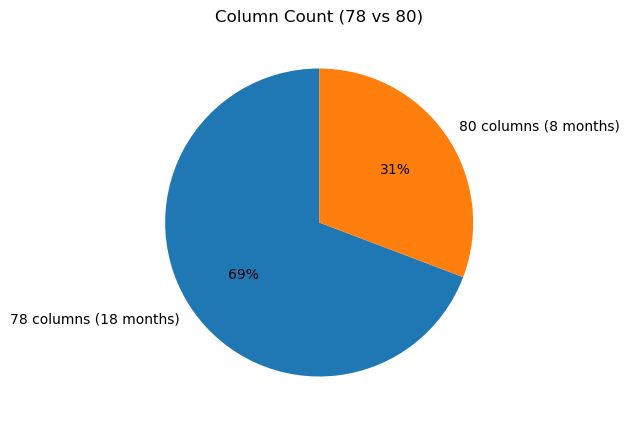

In [66]:
import matplotlib.pyplot as plt

counts = col_counts['n_columns'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts.values,
    labels=[f'{n} columns ({c} months)' for n, c in counts.items()
],
    autopct='%1.0f%%',
    startangle=90,
)
ax.set_title('Column Count (78 vs 80)')
plt.show()

In [67]:
all_cols = sorted(set().union(*schema_by_year_month.values()))
months_sorted = sorted(schema_by_year_month.keys())
columns_existence_per_month = pd.DataFrame(
    { ym: [1 if c in schema_by_year_month[ym] else 0 for c in all_cols] for ym in months_sorted},
    index=all_cols,
)
columns_existence_per_month

,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,...,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
AboveGradeFinishedArea,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFee,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFeeFrequency,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AttachedGarageYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
BasementYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
WaterfrontYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
YearBuilt,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
latfilled,1,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
col_month_counts = pd.Series(
    {c: sum(c in cols for cols in schema_by_year_month.values()) for c in all_cols},
    name='n_months_present'
).sort_values(ascending=False)

col_month_counts

AboveGradeFinishedArea         26
ListAgentEmail                 26
MiddleOrJuniorSchool           26
MainLevelBedrooms              26
MLSAreaMajor                   26
                               ..
lonfilled                       7
BuyerAgencyCompensation         4
BuyerAgencyCompensationType     4
OriginatingSystemSubName        1
OriginatingSystemName           1
Name: n_months_present, Length: 84, dtype: int64

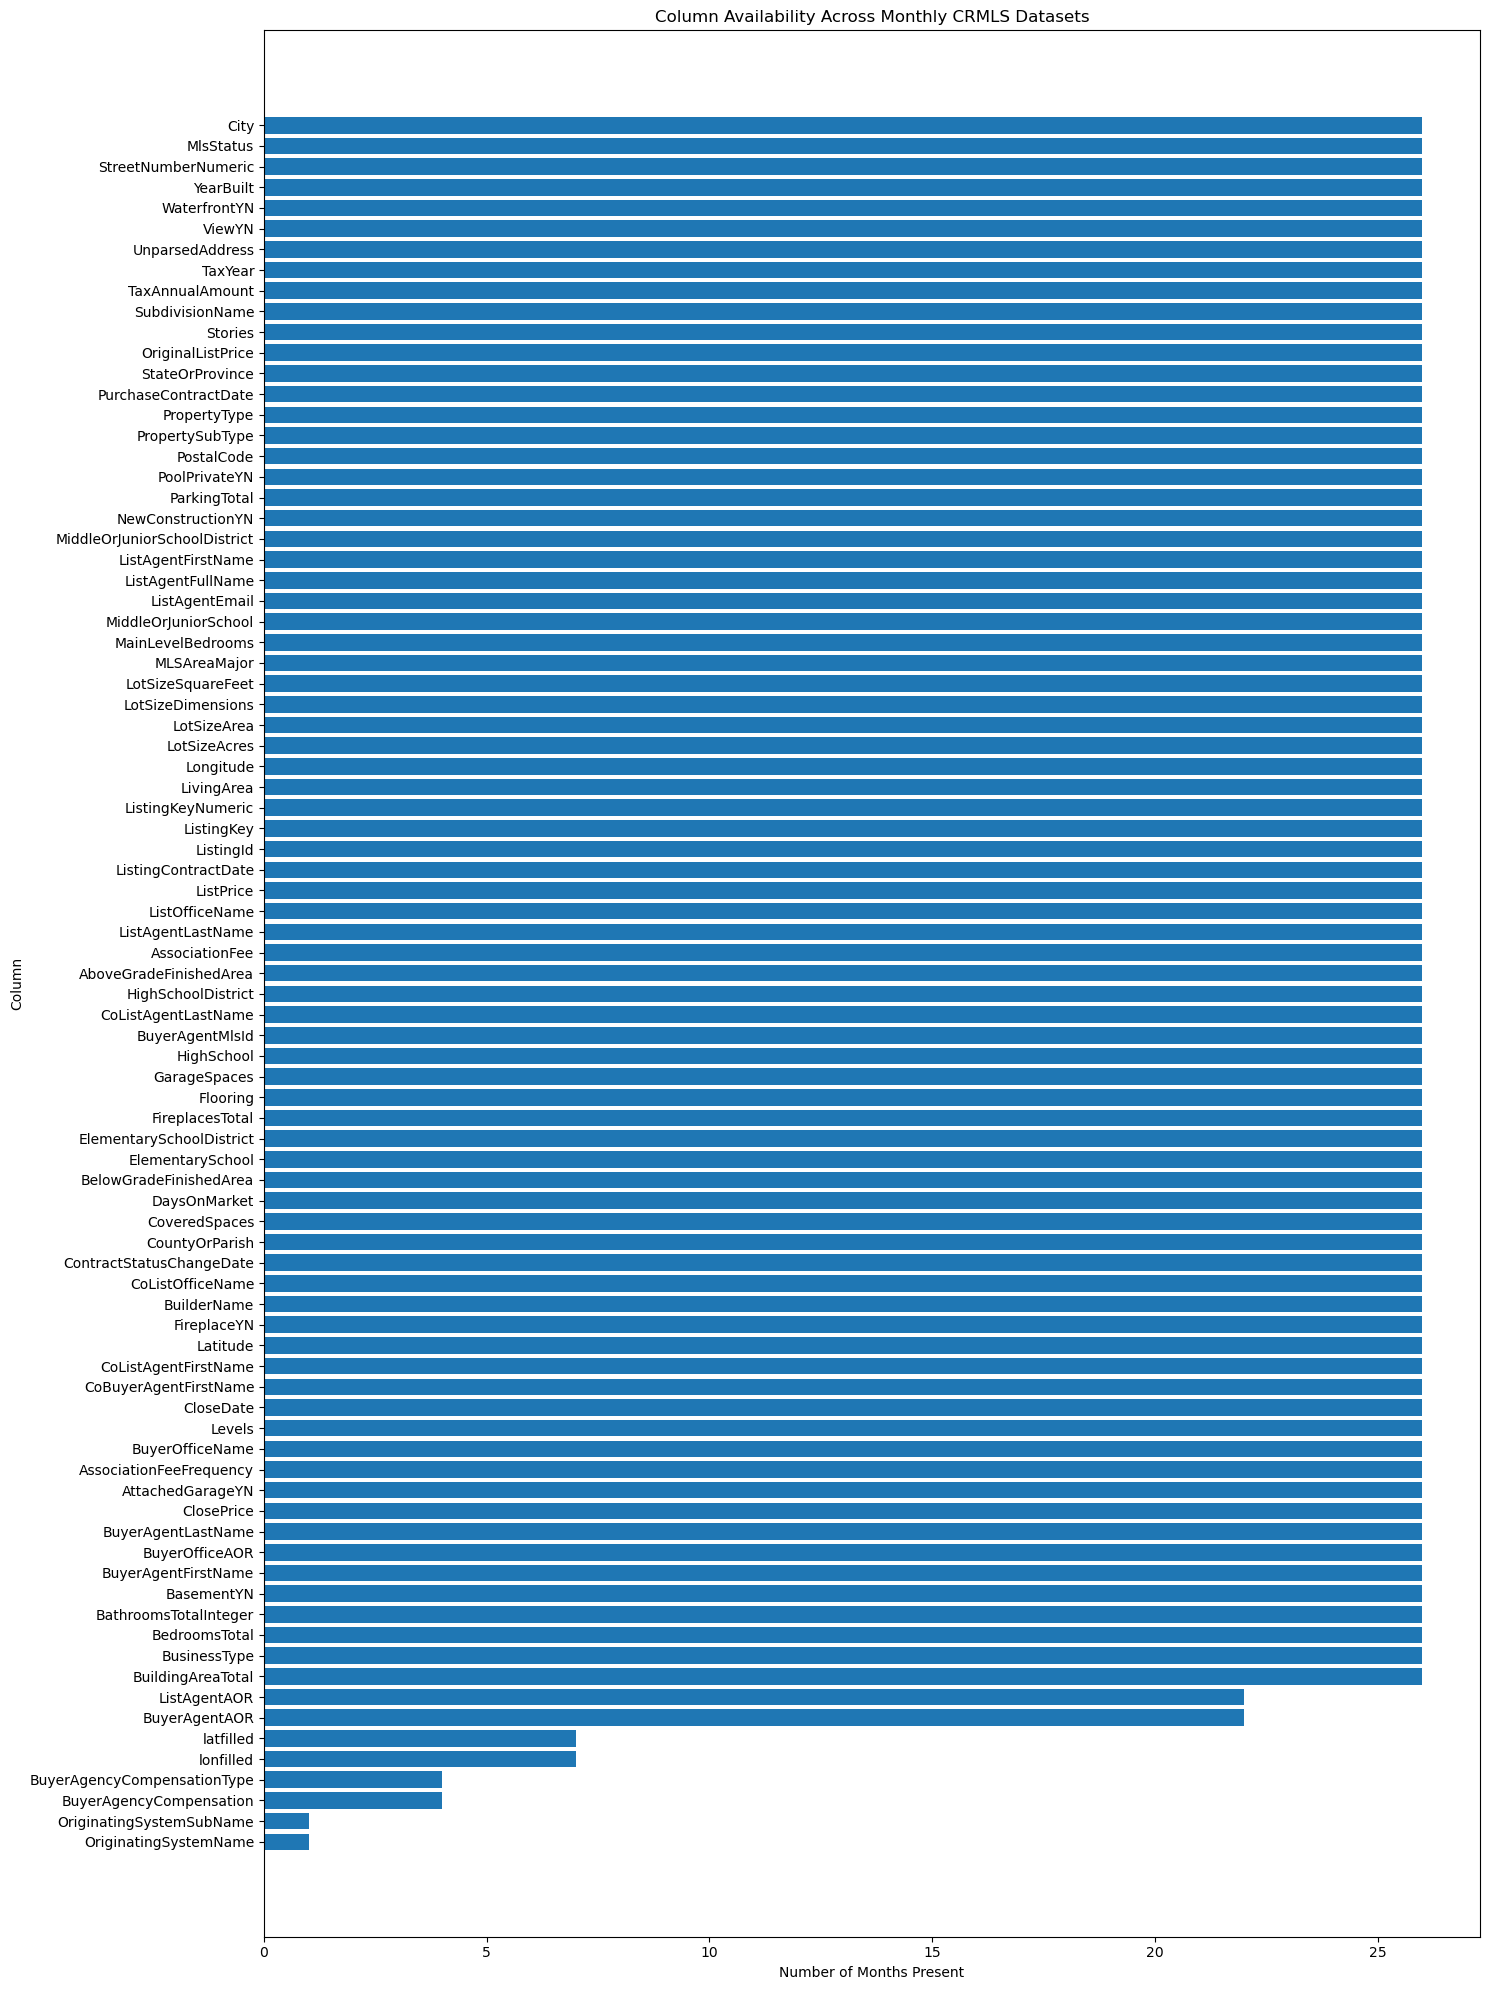

In [69]:
columns_vs_month_count = col_month_counts.sort_values(ascending=True)

plt.figure(figsize=(15, 20))

plt.barh(
    columns_vs_month_count.index,
    columns_vs_month_count.values
)

plt.xlabel("Number of Months Present")
plt.ylabel("Column")
plt.title("Column Availability Across Monthly CRMLS Datasets")

plt.tight_layout()
plt.show()

In [70]:
total_months = len(schema_by_year_month)
print("total months:", total_months)

cols_in_all_months = col_month_counts[col_month_counts == total_months].index
cols_in_all_months

total months: 26


Index(['AboveGradeFinishedArea', 'ListAgentEmail', 'MiddleOrJuniorSchool',
       'MainLevelBedrooms', 'MLSAreaMajor', 'LotSizeSquareFeet',
       'LotSizeDimensions', 'LotSizeArea', 'LotSizeAcres', 'Longitude',
       'LivingArea', 'ListingKeyNumeric', 'ListingKey', 'ListingId',
       'ListingContractDate', 'ListPrice', 'ListOfficeName',
       'ListAgentLastName', 'ListAgentFullName',
       'MiddleOrJuniorSchoolDistrict', 'MlsStatus', 'NewConstructionYN',
       'StreetNumberNumeric', 'YearBuilt', 'WaterfrontYN', 'ViewYN',
       'UnparsedAddress', 'TaxYear', 'TaxAnnualAmount', 'SubdivisionName',
       'Stories', 'OriginalListPrice', 'StateOrProvince',
       'PurchaseContractDate', 'PropertyType', 'PropertySubType', 'PostalCode',
       'PoolPrivateYN', 'ParkingTotal', 'AssociationFee', 'ListAgentFirstName',
       'City', 'BuyerAgentMlsId', 'CloseDate', 'Levels', 'BuyerOfficeName',
       'AssociationFeeFrequency', 'AttachedGarageYN', 'BuyerOfficeAOR',
       'BuyerAgentLastName

#### No Data Type Drift for Each Column

In [71]:
dtype_by_month = apply_per_month(year_month_file_map, lambda f: pd.read_csv(f, low_memory=False).dtypes.astype(str))

dtype_matrix = pd.DataFrame(dtype_by_month).reindex(all_cols)
dtype_matrix.columns = pd.to_datetime(dtype_matrix.columns, format='%Y%m')
dtype_matrix = dtype_matrix.sort_index(axis=1)
dtype_matrix

,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01
AboveGradeFinishedArea,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFee,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFeeFrequency,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
AttachedGarageYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
BasementYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
WaterfrontYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
YearBuilt,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
latfilled,bool,NaN,bool,bool,bool,bool,bool,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
#Find which columns actually drifted:
n_distinct_dtypes = dtype_matrix.apply(lambda row: row.dropna().nunique(), axis=1)
drifted_cols = n_distinct_dtypes[n_distinct_dtypes > 1].sort_values(ascending=False)
drifted_cols

Series([], dtype: int64)

#### General Data Quality

Done:
- count missing values
-  missingness percentage by feature
- investigate whether missingness is systematic
Nice to haves:
- inspect duplicate records
- find ClosePrice <= 0
- look for impossible dates
- check zero/negative LivingArea
- inspect outliers

Making a big dataframe for the training months, January 2024 to February 2026

In [73]:
dfs = []
for ym, f in year_month_file_map.items():
    d = pd.read_csv(f, low_memory=False)
    d['year_month'] = pd.to_datetime(ym, format='%Y%m')
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True) # automatically align columns cross months, mising column becomes NaN

In [74]:
# Task scope
def single_family_residency_only(d):
    return d[(d["PropertyType"] == "Residential") & (d["PropertySubType"] == "SingleFamilyResidence")]

df_all = df  # keep the unfiltered version for reference
df = single_family_residency_only(df_all).copy()
print(f"{len(df_all):,} rows -> {len(df):,} single-family rows")  # expect 568,074 -> 285,683

# Verify the filter
assert (df["PropertyType"] == "Residential").all()
assert (df["PropertySubType"] == "SingleFamilyResidence").all()

568,074 rows -> 285,683 single-family rows


In [75]:
df.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
5,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,NaN,NaN,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN
9,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,NaN,NaN,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN
28,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,0.0,11219.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
29,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,NaN,74487.6,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
31,"Tile,Wood",True,NaN,NaN,NaN,NaN,1061988701,dannyduong@gmail.com,2024-01-31,2340000.0,...,NaN,8712.0,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN


In [76]:
missing_by_month = apply_per_month(
    year_month_file_map,
    lambda f: single_family_residency_only(pd.read_csv(f, low_memory=False)).isna().mean() * 100  # same rows as df
)
missing_matrix = pd.DataFrame(missing_by_month).reindex(all_cols)
missing_matrix.columns = pd.to_datetime(missing_matrix.columns, format='%Y%m')
missing_matrix = missing_matrix.sort_index(axis=1)
missing_matrix

,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01
AboveGradeFinishedArea,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
AssociationFee,28.707042,29.631953,30.960976,31.533935,32.817584,32.419291,31.648976,31.923108,31.460262,33.813882,...,29.914240,30.347834,29.461780,29.264886,29.050279,29.844542,29.109765,27.250120,26.502003,28.005358
AssociationFeeFrequency,76.135544,74.895441,74.626096,74.444880,74.824669,74.372260,74.928988,75.404166,76.377303,77.055155,...,74.840791,74.369712,75.309559,74.611489,75.689595,75.933162,74.514837,74.576758,74.299065,73.222458
AttachedGarageYN,12.040375,11.574655,10.942066,11.071008,10.931964,10.713432,10.995665,11.574037,11.073426,11.184903,...,12.150802,11.640031,12.076936,12.336302,12.456355,11.738299,11.910874,12.778575,12.736983,11.898649
BasementYN,97.740928,97.846090,97.885508,97.653982,97.498373,97.951375,97.428614,97.466420,97.323311,97.343484,...,97.520591,97.256645,97.738154,97.677667,97.730447,97.439521,97.350857,97.714012,97.797063,97.644826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,8.363374,8.071936,7.916452,8.528835,9.109970,9.565564,8.887726,9.120888,8.937574,9.791852,...,9.323257,9.751303,9.352815,9.062336,9.532123,9.876133,9.405483,8.407461,7.463284,8.706329
WaterfrontYN,99.951935,99.926809,99.974214,99.945077,99.963849,99.968115,99.962625,99.975871,99.990833,100.000000,...,99.915089,99.940176,99.975235,99.973808,99.973813,99.916868,99.989732,99.933046,99.919893,99.899542
YearBuilt,0.024033,0.115015,0.051573,0.078462,0.108452,0.039857,0.059800,0.064345,0.091667,0.089090,...,0.178314,0.085463,0.049529,0.052383,0.061103,0.049879,0.051340,0.057389,0.093458,0.033486
latfilled,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
overall_missing_by_month = missing_matrix.mean(axis=0, skipna=True)
overall_missing_by_month.name = 'pct_missing'

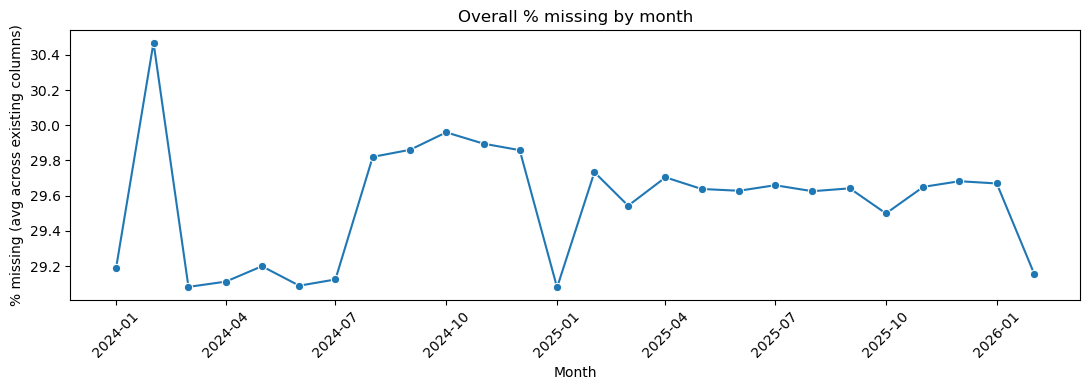

In [78]:
import seaborn as sns 

missing_trend = overall_missing_by_month.reset_index()
missing_trend.columns = ['year_month', 'pct_missing']

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=missing_trend, x='year_month', y='pct_missing', marker='o', ax=ax)
ax.set_title('Overall % missing by month')
ax.set_ylabel('% missing (avg across existing columns)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
missing_by_feature = missing_matrix.mean(axis=1, skipna=True).sort_values(ascending=False) # missingness separately for each monthly file
nonzero = missing_by_feature[missing_by_feature > 0] # actually missing

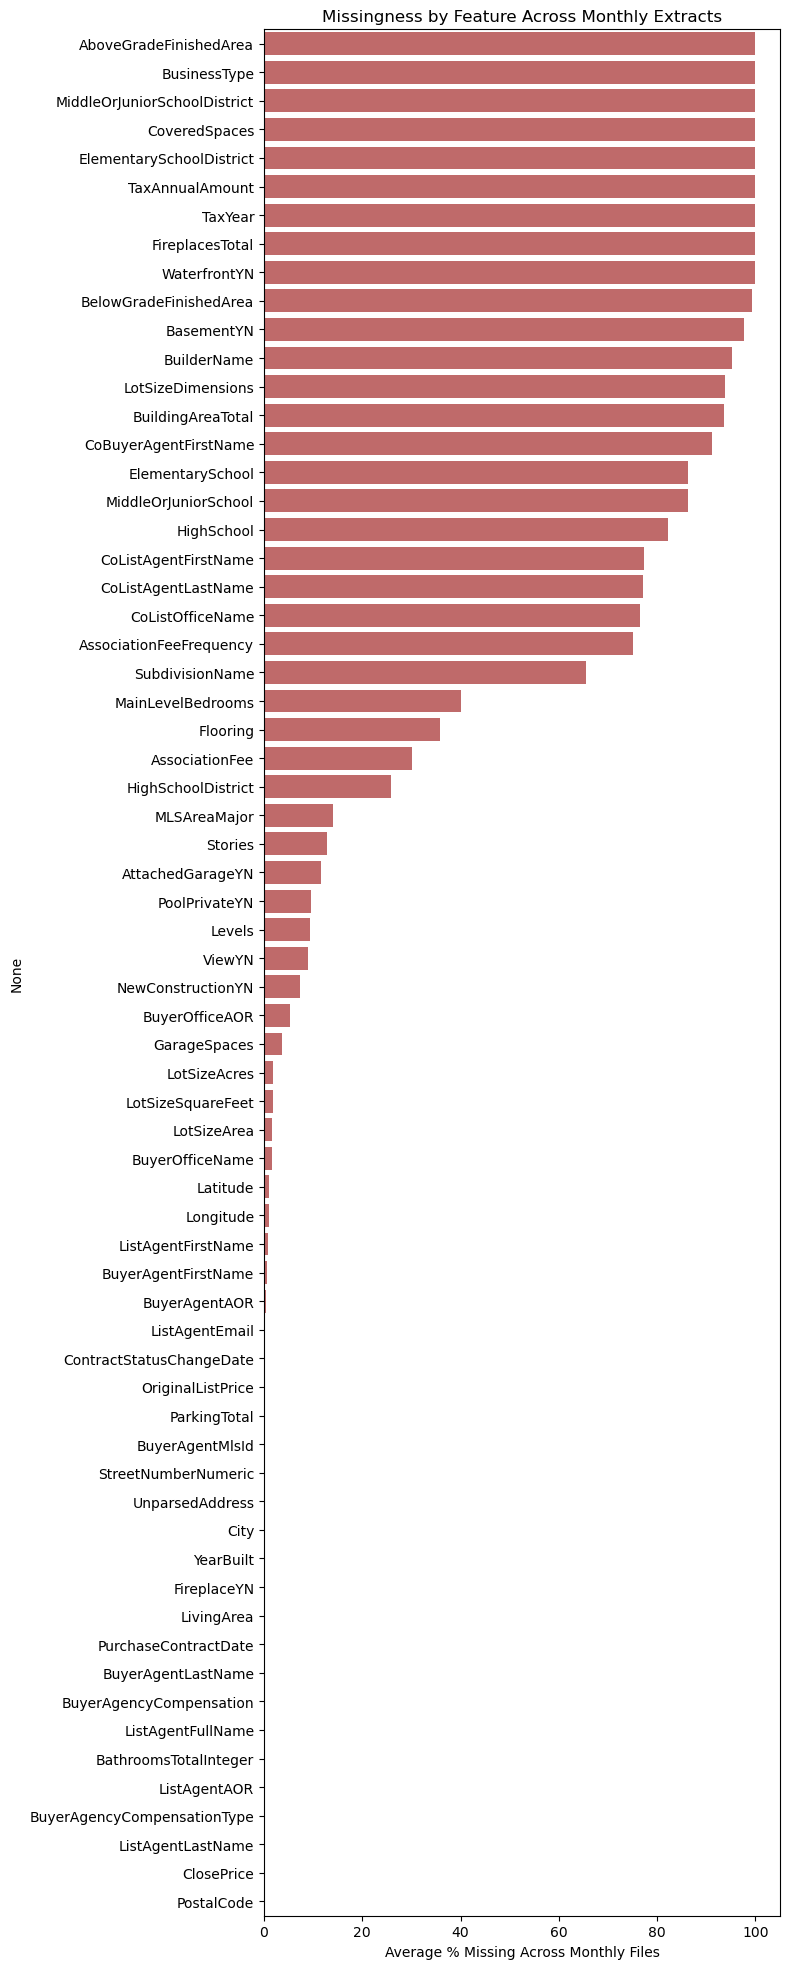

In [80]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(nonzero)))) 
sns.barplot(x=nonzero.values, y=nonzero.index, color='indianred', ax=ax)
ax.set_xlabel('Average % Missing Across Monthly Files')
ax.set_title('Missingness by Feature Across Monthly Extracts')
plt.tight_layout()
plt.show()

In [81]:
overall_missingness = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

overall_missingness_nonzero = overall_missingness[overall_missingness > 0] # nonegative values

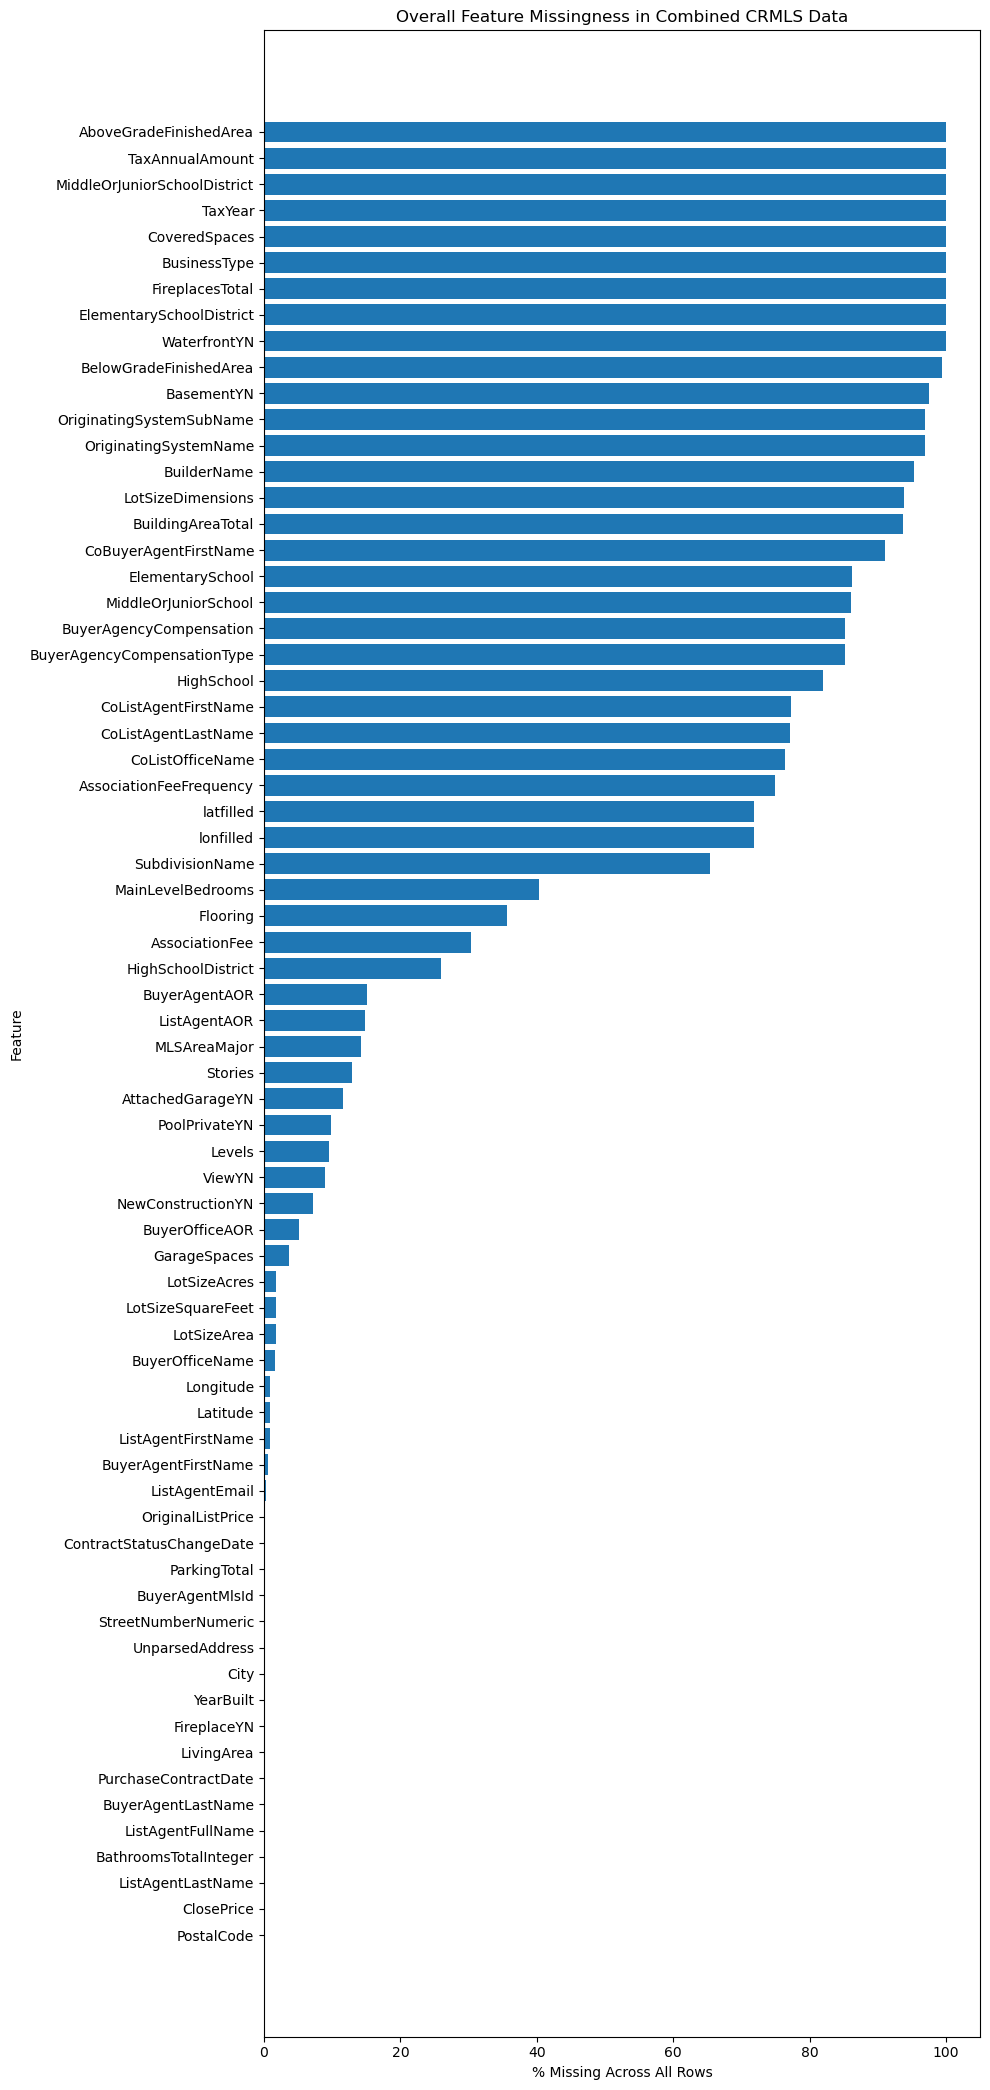

In [82]:
ig, ax = plt.subplots(
    figsize=(10, max(5, 0.3 * len(overall_missingness_nonzero)))
)

ax.barh(
    overall_missingness_nonzero.index[::-1],
    overall_missingness_nonzero.values[::-1]
)

ax.set_xlabel("% Missing Across All Rows")
ax.set_ylabel("Feature")
ax.set_title("Overall Feature Missingness in Combined CRMLS Data")

plt.tight_layout()
plt.show()

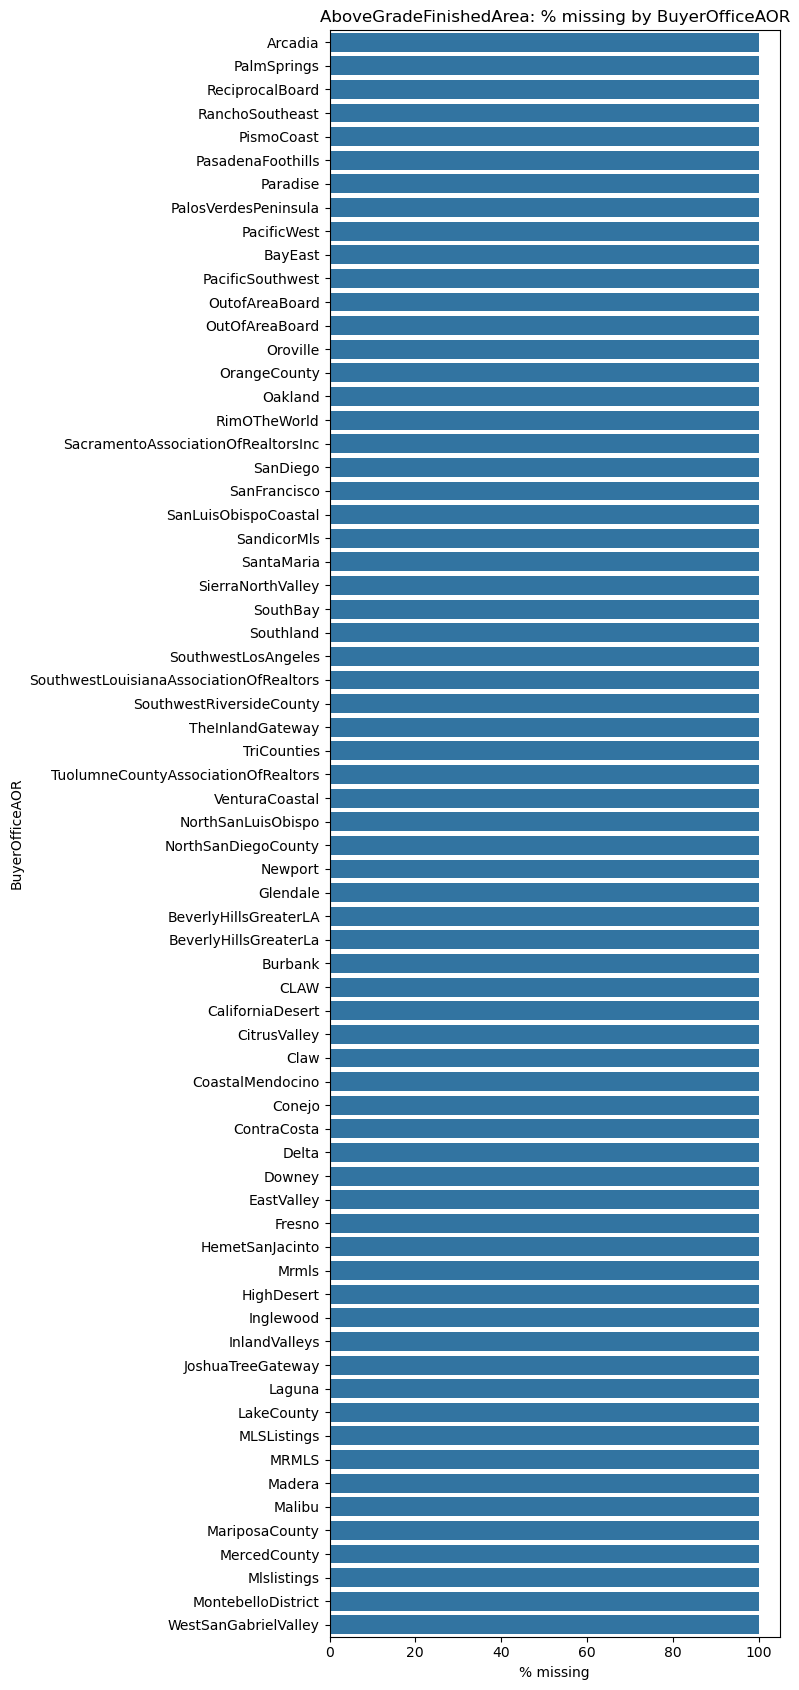

In [83]:
col = 'AboveGradeFinishedArea'  # swap in whatever feature you're checking

missing_by_buyer_offic_board = (
    df.groupby('BuyerOfficeAOR')[col]
    .apply(lambda s: s.isna().mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(missing_by_buyer_offic_board))))
sns.barplot(x=missing_by_buyer_offic_board.values, y=missing_by_buyer_offic_board.index, ax=ax)
ax.set_xlabel('% missing')
ax.set_title(f'{col}: % missing by BuyerOfficeAOR')
plt.tight_layout()
plt.show()

Investingating Duplicate Rows

In [84]:
exact_dupes = df[df.duplicated(keep=False)]
len(exact_dupes)

58

In [85]:
dupe_keys = df[df.duplicated(subset='ListingKey', keep=False)]
dupe_keys.sort_values('ListingKey').head(6)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
136532,"Carpet,Tile",True,NaN,NaN,False,410740.0,1031992525,martincanhelpu@gmail.com,2024-06-21,415740.0,...,0.0,11356.0,NaN,True,True,2024-06-01,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,NaN
231924,"Carpet,Tile",True,NaN,NaN,False,410740.0,1031992525,martincanhelpu@gmail.com,2024-10-18,459900.0,...,0.0,11356.0,NaN,NaN,NaN,2024-10-01,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,NaN
112046,NaN,False,NaN,True,False,750000.0,1037464932,RealEstateSteele@gmail.com,2024-05-25,650000.0,...,0.0,3750.0,NaN,False,False,2024-05-01,PacificWest,PacificWest,NaN,NaN
208611,NaN,False,NaN,True,False,750000.0,1037464932,RealEstateSteele@gmail.com,2024-09-06,665000.0,...,0.0,3750.0,NaN,NaN,NaN,2024-09-01,PacificWest,PacificWest,NaN,NaN
231725,NaN,True,NaN,NaN,False,825000.0,1046689006,isell4u2@yahoo.com,2024-10-29,825000.0,...,0.0,4000.0,NaN,NaN,NaN,2024-10-01,PismoCoast,PismoCoast,NaN,NaN
135852,NaN,True,NaN,NaN,False,825000.0,1046689006,isell4u2@yahoo.com,2024-06-30,825000.0,...,0.0,4000.0,NaN,True,True,2024-06-01,PismoCoast,PismoCoast,NaN,NaN


In [86]:
# dupe_summary = (
#     dupe_keys
#     .groupby('ListingKey')['year_month']
#     .agg(['nunique', 'count'])
#     .sort_values('count', ascending=False)
# )
# dupe_summary # what does this tell us?

Likely: AboveGradeFinishedArea / BelowGradeFinishedArea are part of the RESO MLS data standard's basement-distinction fields standard for Midwest and Northeast. California housing stock rarely has basements, and CRMLS input forms likely don't even surface these fields to agents as something to fill in, even though the column exists in the schema. So it's not "missing data" in the sense of a reporting gap.

#### Understand What We Want to Predict: ClosePrice

We want to use data science, perhaps even some reference to previous similar work, to accurately and reliable predict the closePrice.

Noteworthy background:

- Hedonic pricing theory (Rosen, 1974, "Hedonic Prices and Implicit Markets", JPE) is the foundational justification for predicting price from property characteristics (sqft, bedrooms, location) in the first place. It's the theoretical basis for the whole feature set to be built (LivingArea, BedroomsTotal, geography, etc.).
- De Cock (2011), "Ames, Iowa: Alternative to the Boston Housing Data..." (Journal of Statistics Education) is the standard pedagogical reference for right-skewed house prices, outliers from unusual sales, and the now-standard practice of modeling log(SalePrice) rather than raw price. It's the source dataset behind the Kaggle "House Prices" competition, and the skew/log-transform diagnostic presented in the work.
- Since errors are multi-scale (a $50K miss means something very different on a $200K condo vs a $3M home), percentage-based metrics (MAPE/MdAPE) or RMSE computed in log-space are preferred over raw RMSE/MAE. This reflects how Zillow publicly reports Zestimate accuracy using median absolute percentage error, precisely because raw dollar error isn't comparable across the price spectrum.

In [87]:
df["ClosePrice"].describe()

count    2.856810e+05
mean     1.288096e+06
std      5.203254e+06
min      0.000000e+00
25%      6.250000e+05
50%      8.900000e+05
75%      1.429900e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

The maximum is roughly \$989,500,000, and it's a single-family home, so it's almost certainly a data-entry error rather than a real sale. This extreme outlier squeezes everything else into the smallest bins.

<Axes: xlabel='ClosePrice', ylabel='Count'>

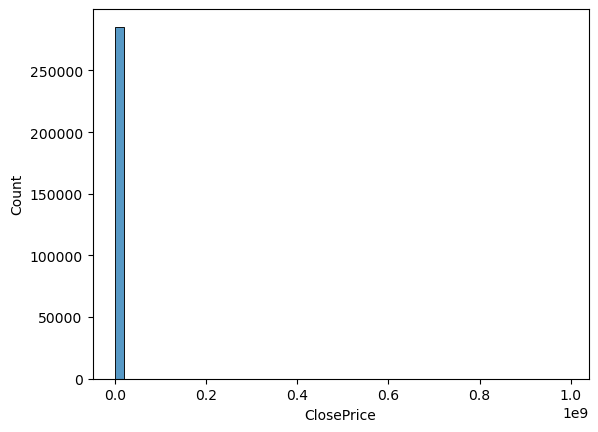

In [88]:
sns.histplot(df["ClosePrice"], bins=50)



Close price is non-negative.

In [89]:
df[df["ClosePrice"] < 0]

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName


ClosePrice can be 0.

In [90]:
df["ClosePrice"].min()

0.0

Thankfully, there's only one row that's like that that.

In [91]:
zero_price_count = (df["ClosePrice"] == 0).sum()
zero_price_count

1

In [92]:
df.loc[
    df["ClosePrice"] == 0,
    ["ClosePrice", "CloseDate", "City", "LivingArea", "PropertyType", "PropertySubType"]
]

,ClosePrice,CloseDate,City,LivingArea,PropertyType,PropertySubType
407174,0.0,2025-07-30,Temple City,2001.0,Residential,SingleFamilyResidence


Why can close price be 0?

In [93]:
print('skew:', df['ClosePrice'].skew())
print('kurtosis:', df['ClosePrice'].kurt())

skew: 145.15410635017864
kurtosis: 23627.410249456694


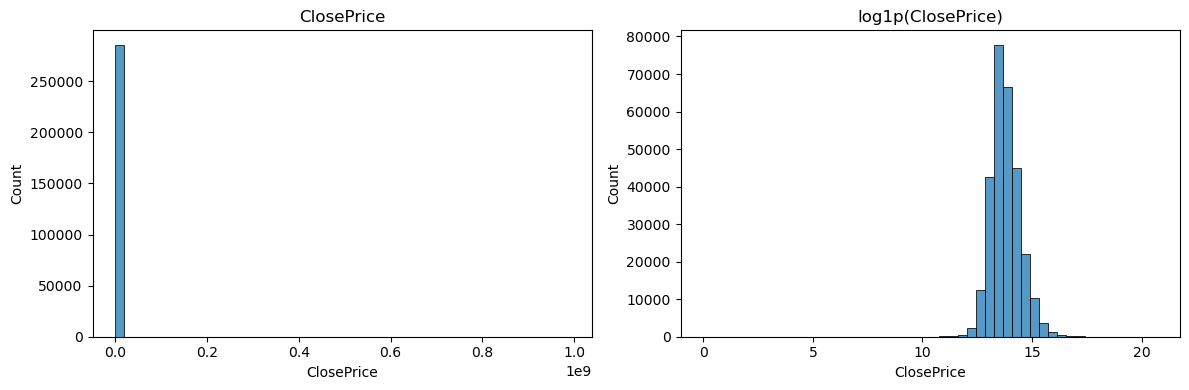

In [94]:
log_price = np.log1p(df['ClosePrice'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ClosePrice'], bins=50, ax=axes[0]); axes[0].set_title('ClosePrice')
sns.histplot(log_price, bins=50, ax=axes[1]); axes[1].set_title('log1p(ClosePrice)')
plt.tight_layout()
plt.show()

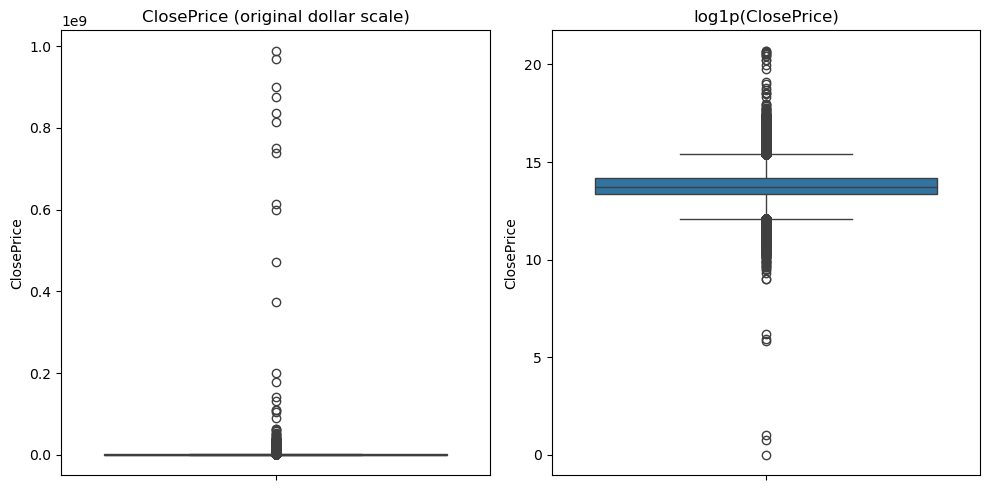

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=df['ClosePrice'], ax=axes[0])
axes[0].set_title('ClosePrice (original dollar scale)') # outlier makes others look close to 0

sns.boxplot(y=log_price, ax=axes[1])
axes[1].set_title('log1p(ClosePrice)')

plt.tight_layout()
plt.show()

Nice to haves for later:
Handbook describes real-estate prices and errors as multi-scale and right-skewed, emaphasizing percentage-based metrics such as MdAPE as appropriate.

#### Numeric variables

Then analyze things like:
- LivingArea
- LotSizeSquareFeet
- BedroomsTotal
- BathroomsTotalInteger
- YearBuilt
- TaxAnnualAmount
- Stories
- FireplacesTotal

distribution
missing %
zero / impossible values
outliers
unique values

In [96]:
numeric_cols_all = df.select_dtypes(include='number', exclude="bool").columns
numeric_cols_all

Index(['OriginalListPrice', 'ListingKey', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'FireplacesTotal', 'AboveGradeFinishedArea', 'ListingKeyNumeric',
       'TaxAnnualAmount', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
       'StreetNumberNumeric', 'BathroomsTotalInteger',
       'BuyerAgencyCompensation', 'TaxYear', 'BuildingAreaTotal',
       'BedroomsTotal', 'ElementarySchoolDistrict', 'BelowGradeFinishedArea',
       'CoveredSpaces', 'Stories', 'LotSizeArea', 'MainLevelBedrooms',
       'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet',
       'MiddleOrJuniorSchoolDistrict'],
      dtype='object')

In [97]:
df["ElementarySchoolDistrict"].dropna() # expect nothing left bc the chart said it was 100% missing

Series([], Name: ElementarySchoolDistrict, dtype: float64)

In [98]:
exclude_numeric = [
    # already did this
    "ClosePrice",

    # identifiers
    "ListingKey",
    "ListingKeyNumeric",
    "StreetNumberNumeric",

    # acoording to handbook: rise from the sale process rather than intrinsic property characteristics
    "ListPrice",
    "OriginalListPrice",
    "DaysOnMarket",

    # seems to be all missing
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchoolDistrict",
]

In [99]:
check_missing = [
    "AboveGradeFinishedArea",
    "FireplacesTotal",
    "CoveredSpaces",
    "TaxYear",
    "TaxAnnualAmount",
    "BelowGradeFinishedArea",
    "BuyerAgencyCompensation",
]
df[check_missing].isna().mean().mul(100).sort_values(ascending=False)

AboveGradeFinishedArea     100.000000
FireplacesTotal            100.000000
CoveredSpaces              100.000000
TaxYear                    100.000000
TaxAnnualAmount            100.000000
BelowGradeFinishedArea      99.389883
BuyerAgencyCompensation     85.211931
dtype: float64

In [100]:
all_missing_numeric = [
    col for col in numeric_cols_all
    if df[col].isna().all()
]
exclude_numeric = list(set(exclude_numeric + all_missing_numeric))
exclude_numeric

['ListingKey',
 'ListPrice',
 'FireplacesTotal',
 'ListingKeyNumeric',
 'ElementarySchoolDistrict',
 'TaxYear',
 'ClosePrice',
 'OriginalListPrice',
 'TaxAnnualAmount',
 'DaysOnMarket',
 'StreetNumberNumeric',
 'MiddleOrJuniorSchoolDistrict',
 'AboveGradeFinishedArea',
 'CoveredSpaces']

In [101]:
numeric_cols = numeric_cols_all.difference(exclude_numeric)
numeric_cols

Index(['AssociationFee', 'BathroomsTotalInteger', 'BedroomsTotal',
       'BelowGradeFinishedArea', 'BuildingAreaTotal',
       'BuyerAgencyCompensation', 'GarageSpaces', 'Latitude', 'LivingArea',
       'Longitude', 'LotSizeAcres', 'LotSizeArea', 'LotSizeSquareFeet',
       'MainLevelBedrooms', 'ParkingTotal', 'Stories', 'YearBuilt'],
      dtype='object')

#### What does each numeric column look like on its own?

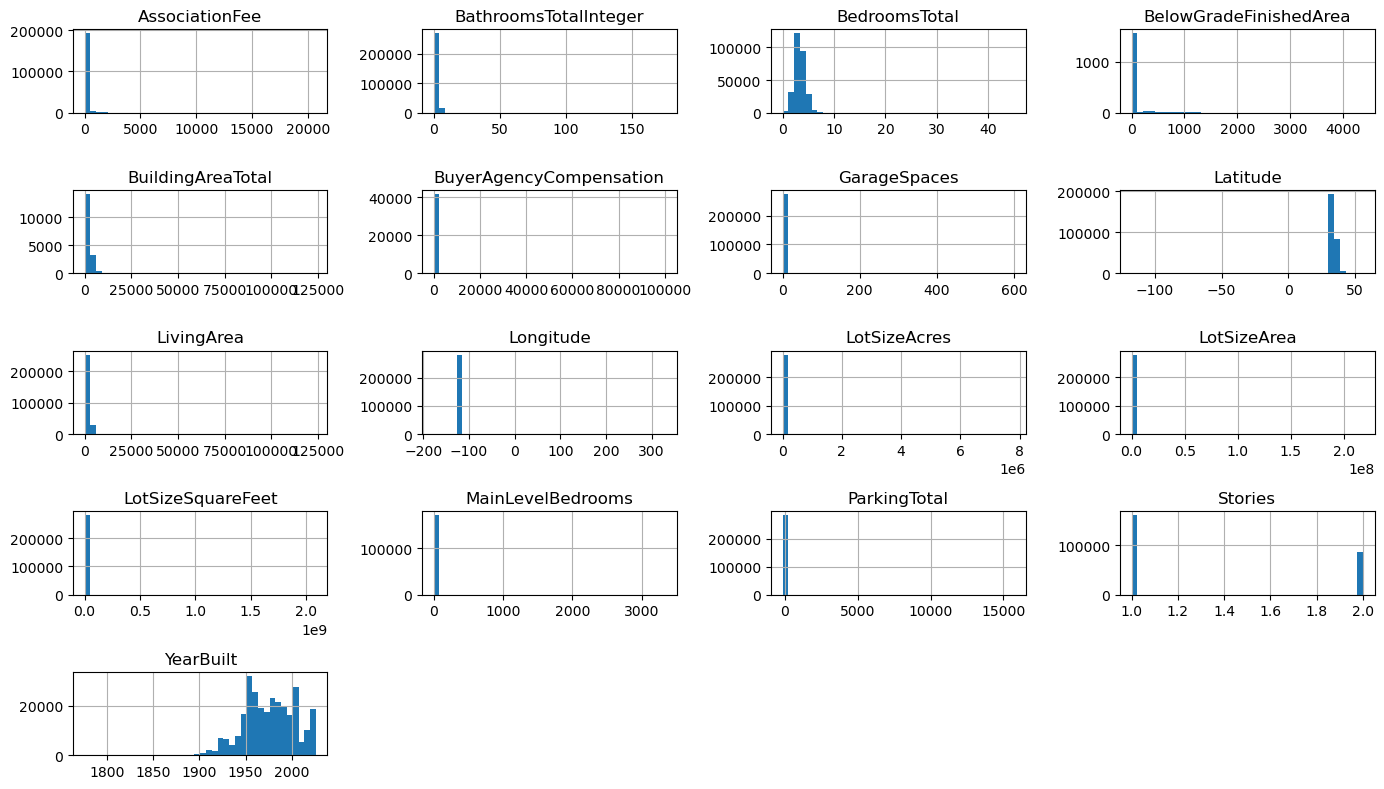

In [102]:
df[numeric_cols].describe().T.assign(missing_pct=df[numeric_cols].isna().mean() * 100)

df[numeric_cols].hist(figsize=(14, 8), bins=40)
plt.tight_layout()
plt.show()

#### Geography
Location is one of the major predictive feature families.

### Geographical Interactions
- LivingArea vs geography
- Plot median price vs. living area separately for several cities.

##### For each City, how many records do I have, and what is the median ClosePrice in that city?

In [103]:
df.groupby("City")["ClosePrice"].agg(
    count="size",
    median="median"
).sort_values("median", ascending=False)

,count,median
City,,
Glennville,2,450092500.0
Belvedere,1,9875000.0
Montecito,39,8108000.0
Atherton,113,7800000.0
Newport Coast,155,7450000.0
...,...,...
Onyx,1,80000.0
Covelo,1,70000.0
Litchfield,1,50000.0


#### Repeat for MLSAreaMajor, CountyOrParish

In [104]:
df.groupby("MLSAreaMajor")["ClosePrice"].agg(
    count="size",
    median="median"
).sort_values("median", ascending=False)

,count,median
MLSAreaMajor,,
GLNV - Glennville,2,450092500.0
CR - Crystal Cove,30,12777500.0
C32 - Malibu Beach,46,12750000.0
SH - Shady Canyon,28,10140000.0
MCTO - Montecito,86,7471273.5
...,...,...
PL03 - Lassen County,2,100000.0
ONYX - Onyx,1,80000.0
NLND - Niland,1,55000.0


In [105]:
df.groupby("CountyOrParish")["ClosePrice"].agg(
    count="size",
    median="median"
).sort_values("median", ascending=False)

,count,median
CountyOrParish,,
Del Norte,1,2485000.0
San Mateo,5073,2030000.0
Santa Clara,11864,1908000.0
Marin,90,1447500.0
Orange,26746,1385000.0
...,...,...
Imperial,247,315000.0
Modoc,2,282000.0
Sierra,1,255000.0


##### Plot median price vs. living area separately for several cities.


In [106]:
# granular approve
top_cities = df['City'].value_counts().head(6).index 
subset = df[df['City'].isin(top_cities)].copy()

# binned, less granular approach (might be good for outliers and seeing general trend)
subset['LivingArea_bin'] = (subset['LivingArea'] // 250) * 250  # 250 sqft buckets
subset.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName,LivingArea_bin
31,"Tile,Wood",True,NaN,NaN,NaN,NaN,1061988701,dannyduong@gmail.com,2024-01-31,2340000.0,...,8712.0,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN,2250.0
37,Wood,True,NaN,NaN,False,1050000.0,1060223286,aliciao@kw.com,2024-01-16,1060000.0,...,13029.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN,1750.0
42,"Carpet,Tile",True,NaN,NaN,False,1080000.0,1059968375,Sold@TrishaDaly.com,2024-01-31,1080000.0,...,NaN,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN,1000.0
56,NaN,False,NaN,NaN,True,8795000.0,1059616313,ray@ray4realty.com,2024-01-31,8720000.0,...,11989.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN,6250.0
62,NaN,False,NaN,NaN,False,820650.0,1059608655,Nate@SDHomesNow.com,2024-01-30,820650.0,...,5500.0,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN,1250.0


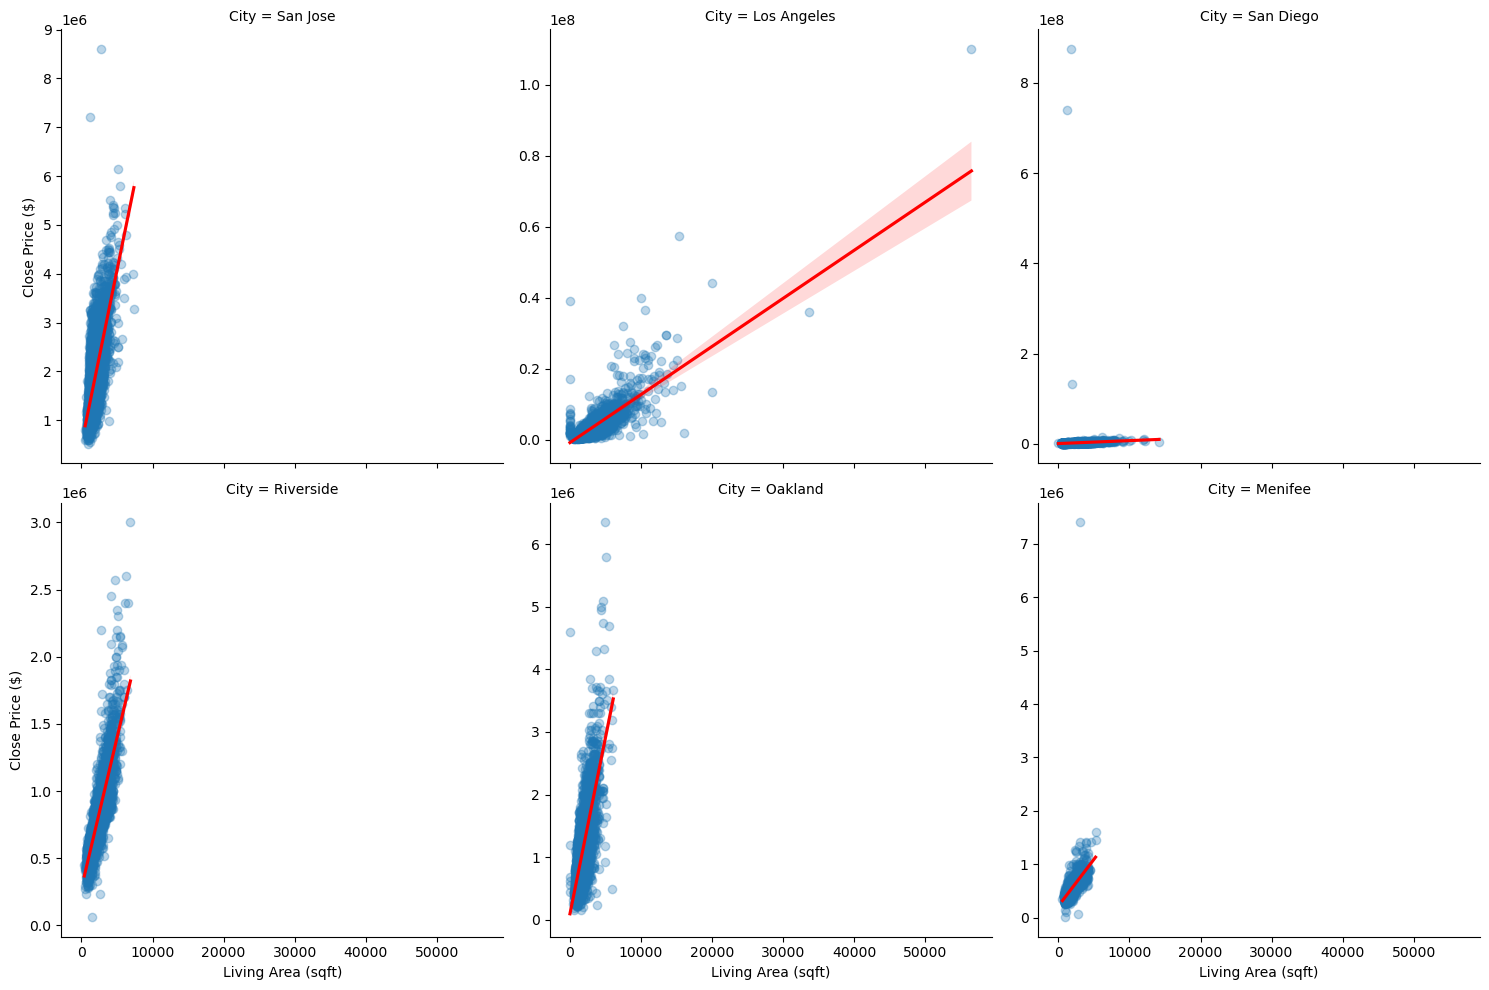

In [107]:
# raw scatter
living_area_closing_price_graph = sns.lmplot(
    data=subset, x='LivingArea', y='ClosePrice',
    col='City', col_wrap=3,
    scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'},
    facet_kws={'sharey': False},
)
living_area_closing_price_graph.set_axis_labels('Living Area (sqft)', 'Close Price ($)')
plt.show()

#### Categorical 

In [108]:
geo_df = df[
    (df["ClosePrice"] > 0) &
    (df["LivingArea"] > 0) &
    df["City"].notna()
].copy()

#Keep cities with reasonable support
city_counts = geo_df["City"].value_counts()
valid_cities = city_counts[city_counts >= 1000].index

geo_df = geo_df[geo_df["City"].isin(valid_cities)].copy()
geo_df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,year_month,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
31,"Tile,Wood",True,NaN,NaN,NaN,NaN,1061988701,dannyduong@gmail.com,2024-01-31,2340000.0,...,NaN,8712.0,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN
37,Wood,True,NaN,NaN,False,1050000.0,1060223286,aliciao@kw.com,2024-01-16,1060000.0,...,NaN,13029.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
42,"Carpet,Tile",True,NaN,NaN,False,1080000.0,1059968375,Sold@TrishaDaly.com,2024-01-31,1080000.0,...,NaN,NaN,NaN,True,True,2024-01-01,NaN,NaN,NaN,NaN
45,NaN,True,NaN,NaN,False,815000.0,1059883015,kwalkerproperties@gmail.com,2024-01-31,815000.0,...,305.0,9220.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN
46,Vinyl,False,NaN,NaN,False,800000.0,1059880125,skh8828@gmail.com,2024-01-31,800000.0,...,0.0,5414.0,NaN,False,False,2024-01-01,NaN,NaN,NaN,NaN


In [109]:
# Size bands
geo_df["LivingAreaBand"] = (geo_df['LivingArea'] // 250) * 250

city_size_summary = (
    geo_df.groupby(
        ["City", "LivingAreaBand"],
        observed=True
    )["ClosePrice"]
    .agg(
        n="size",
        median_price="median"
    )
    .reset_index()
)

# Don't interpret tiny city/size combinations
city_size_summary = city_size_summary[
    city_size_summary["n"] >= 30
]

city_size_summary

,City,LivingAreaBand,n,median_price
1,Anaheim,750.0,40,764000.0
2,Anaheim,1000.0,250,851000.0
3,Anaheim,1250.0,367,900000.0
4,Anaheim,1500.0,284,949950.0
5,Anaheim,1750.0,194,1010000.0
...,...,...,...,...
1601,Yorba Linda,2500.0,89,1575000.0
1602,Yorba Linda,2750.0,71,1666000.0
1603,Yorba Linda,3000.0,71,1770000.0
1604,Yorba Linda,3250.0,47,1935000.0


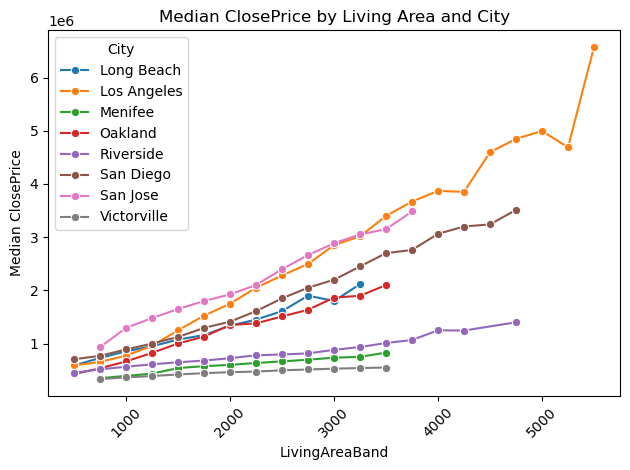

In [110]:
top_cities = (
    geo_df["City"]
    .value_counts()
    .head(8)
    .index
)

plot_df = city_size_summary[
    city_size_summary["City"].isin(top_cities)
]

sns.lineplot(
    data=plot_df,
    x="LivingAreaBand",
    y="median_price",
    hue="City",
    marker="o"
)

plt.xticks(rotation=45)
plt.ylabel("Median ClosePrice")
plt.title("Median ClosePrice by Living Area and City")
plt.tight_layout()
plt.show()